# Analyze adaptive root data

In [2]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent
SRC = ROOT / "src"
sys.path.insert(0, str(SRC))

import time
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd
import seaborn as sns
from helpers.sample import make_sample, stopping_time

In [4]:
summary_results = pd.read_csv(ROOT / "data" / "adaptive_root_summary.csv")

In [5]:
summary_results.head()

,theta,N,alpha,lambda,adaptive_power,sd_adaptive_power,mean_adaptive_value,mean_stopping_time,mean_stopping_fraction,early_stop_prob,mean_theta_hat_at_stop,mean_b_hat_at_stop,mean_last_b_hat,mean_valid_root_looks,mean_invalid_root_looks,n_success
0,0.1,1000,0.05,0.5,0.254,0.435734,0.264076,271.876,0.271876,0.998,0.087118,0.231637,0.231283,236.386,35.488,500
1,0.1,2000,0.05,0.5,0.458,0.498732,0.461469,754.106,0.377053,1.000,0.080125,0.436716,0.436716,707.702,46.404,500
2,0.1,5000,0.05,0.5,0.810,0.392694,0.814226,2503.036,0.500607,1.000,0.090983,0.810928,0.810928,2458.006,45.030,500
3,0.1,10000,0.05,0.5,0.980,0.140140,0.981481,4674.174,0.467417,1.000,0.099989,0.981402,0.981402,4619.314,54.860,500
4,0.5,1000,0.05,0.5,1.000,0.000000,0.999991,328.212,0.328212,1.000,0.503124,0.999990,0.999990,326.314,1.898,500


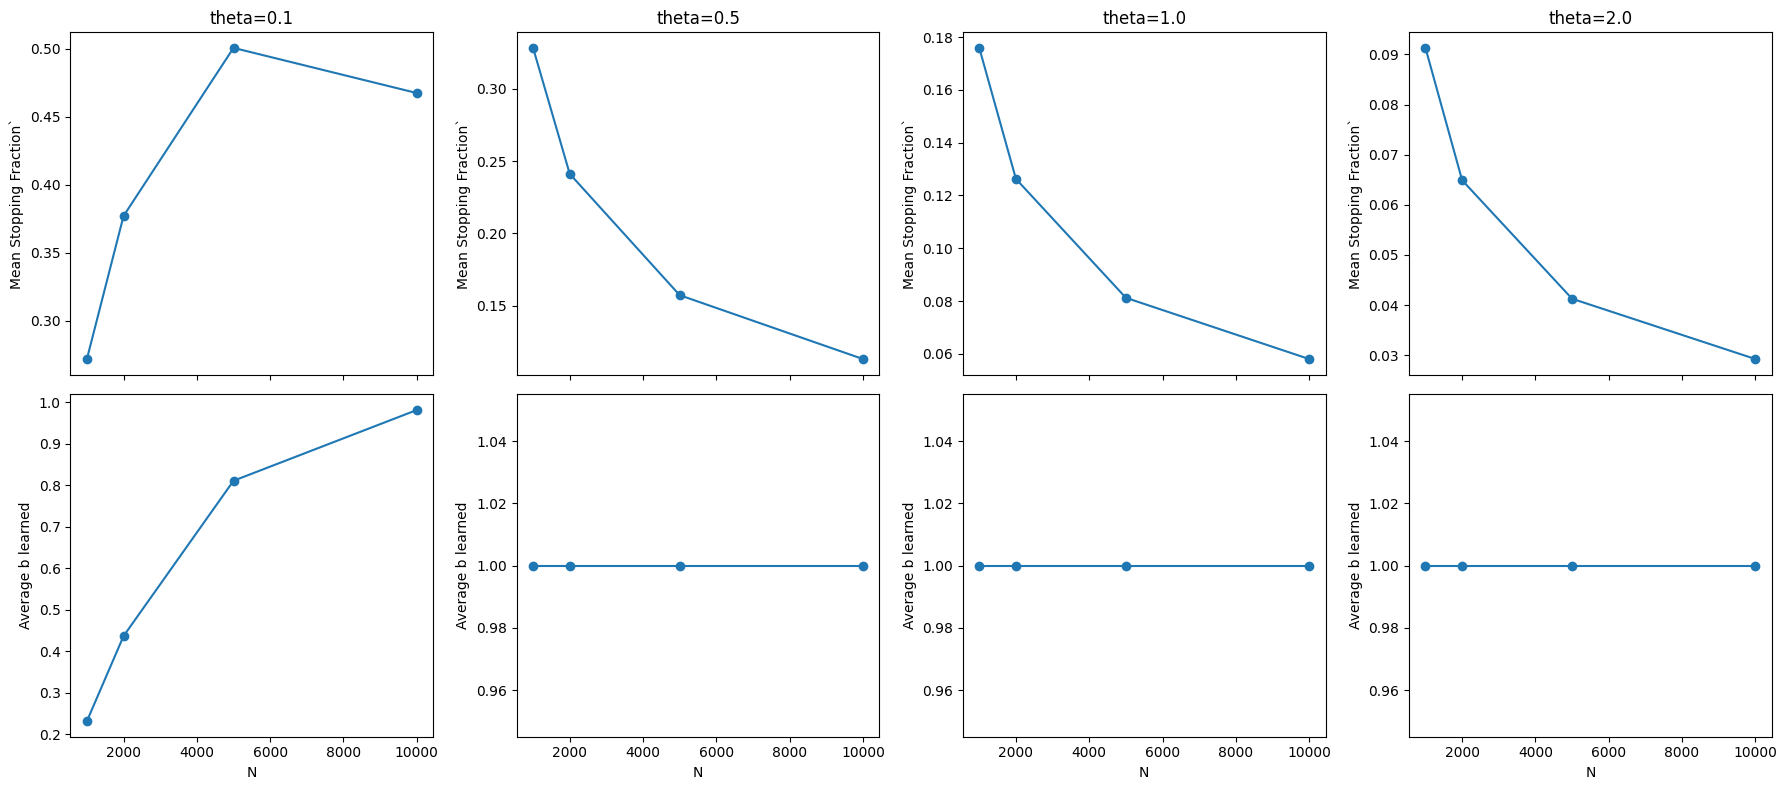

In [9]:
thetas = sorted(summary_results["theta"].unique())

fig, axes = plt.subplots(
    2,
    len(thetas),
    figsize=(4.5 * len(thetas), 8),
    sharex=True,
    sharey=False,
)

# make axes indexable as axes[row, col] even if len(thetas) == 1
if len(thetas) == 1:
    axes = axes.reshape(2, 1)

for i, theta in enumerate(thetas):
    subset = (
        summary_results[summary_results["theta"] == theta]
        .sort_values("N")
    )

    ax_top = axes[0, i]
    ax_bottom = axes[1, i]

    ax_top.plot(
        subset["N"],
        subset["mean_stopping_fraction"],   # replace with your actual column name
        marker="o",
    )

    ax_bottom.plot(
        subset["N"],
        subset["mean_b_hat_at_stop"],      # replace with your actual column name
        marker="o",
    )

    ax_top.set_title(f"theta={theta}")
    ax_top.set_ylabel("Mean Stopping Fraction`")

    ax_bottom.set_xlabel("N")
    ax_bottom.set_ylabel("Average b learned")

plt.tight_layout()
plt.show()

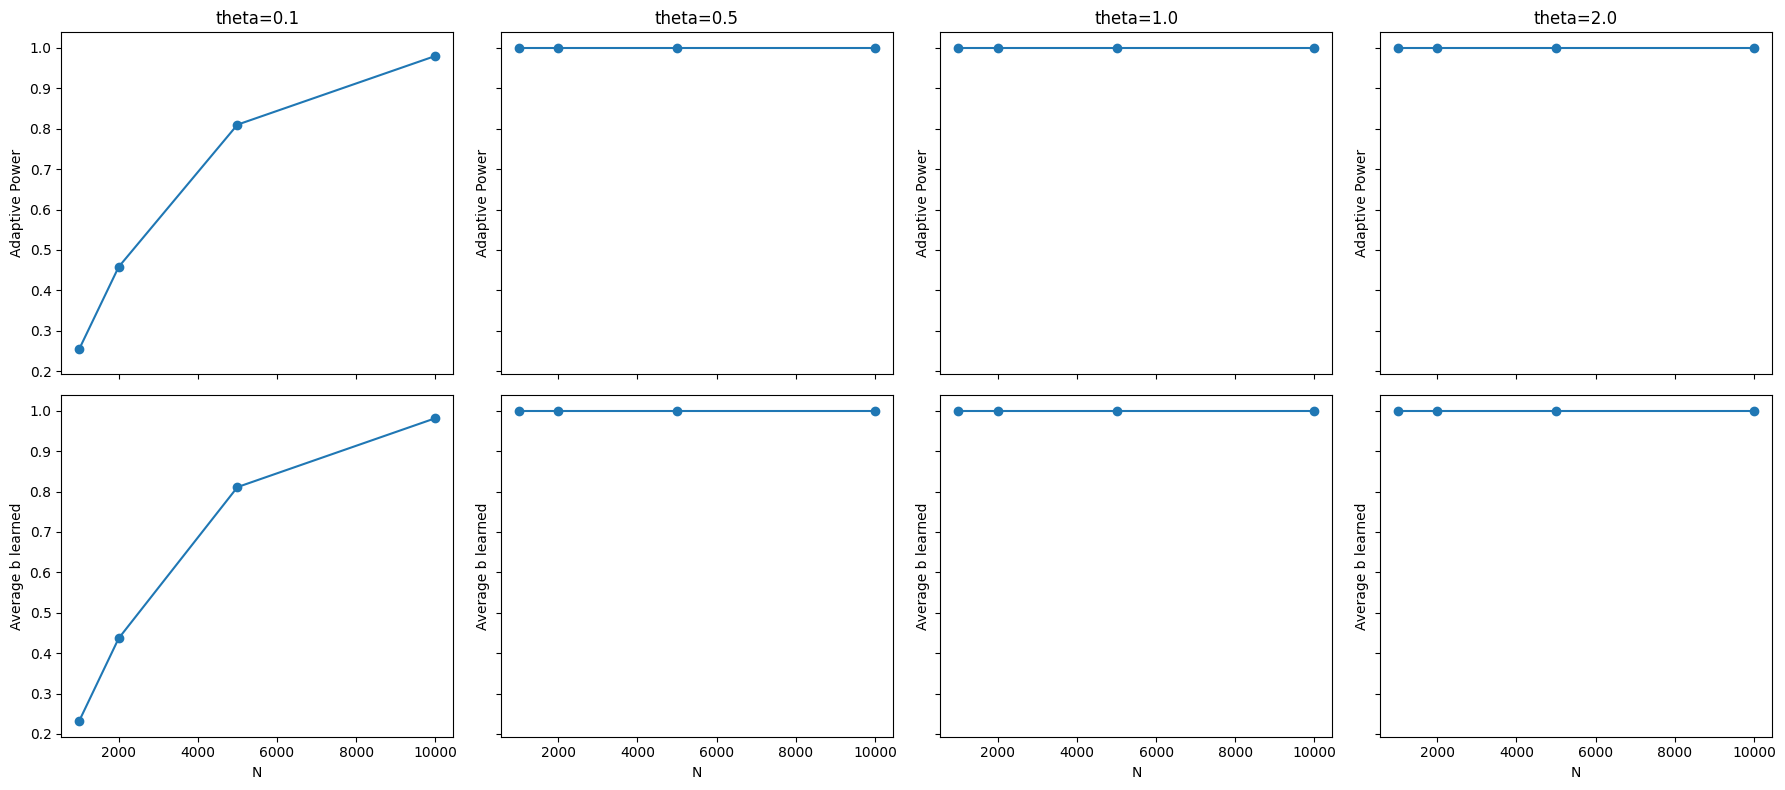

In [10]:
thetas = sorted(summary_results["theta"].unique())

fig, axes = plt.subplots(
    2,
    len(thetas),
    figsize=(4.5 * len(thetas), 8),
    sharex=True,
    sharey=True,
)

# make axes indexable as axes[row, col] even if len(thetas) == 1
if len(thetas) == 1:
    axes = axes.reshape(2, 1)

for i, theta in enumerate(thetas):
    subset = (
        summary_results[summary_results["theta"] == theta]
        .sort_values("N")
    )

    ax_top = axes[0, i]
    ax_bottom = axes[1, i]

    ax_top.plot(
        subset["N"],
        subset["adaptive_power"],   # replace with your actual column name
        marker="o",
    )

    ax_bottom.plot(
        subset["N"],
        subset["mean_b_hat_at_stop"],      # replace with your actual column name
        marker="o",
    )

    ax_top.set_title(f"theta={theta}")
    ax_top.set_ylabel("Adaptive Power")

    ax_bottom.set_xlabel("N")
    ax_bottom.set_ylabel("Average b learned")

plt.tight_layout()
plt.show()

In [12]:
summary_results["seq_util"] = 0.5 * summary_results["mean_stopping_fraction"] - 0.5 * summary_results["adaptive_power"]
summary_results["std_util"] = 0.5 - 0.5 * (1 - scipy.stats.norm.cdf(scipy.stats.norm.ppf(1 - summary_results["alpha"]) - np.sqrt(summary_results["N"]) * summary_results["theta"]))

summary_results["util_diff"] = summary_results["seq_util"] - summary_results["std_util"]

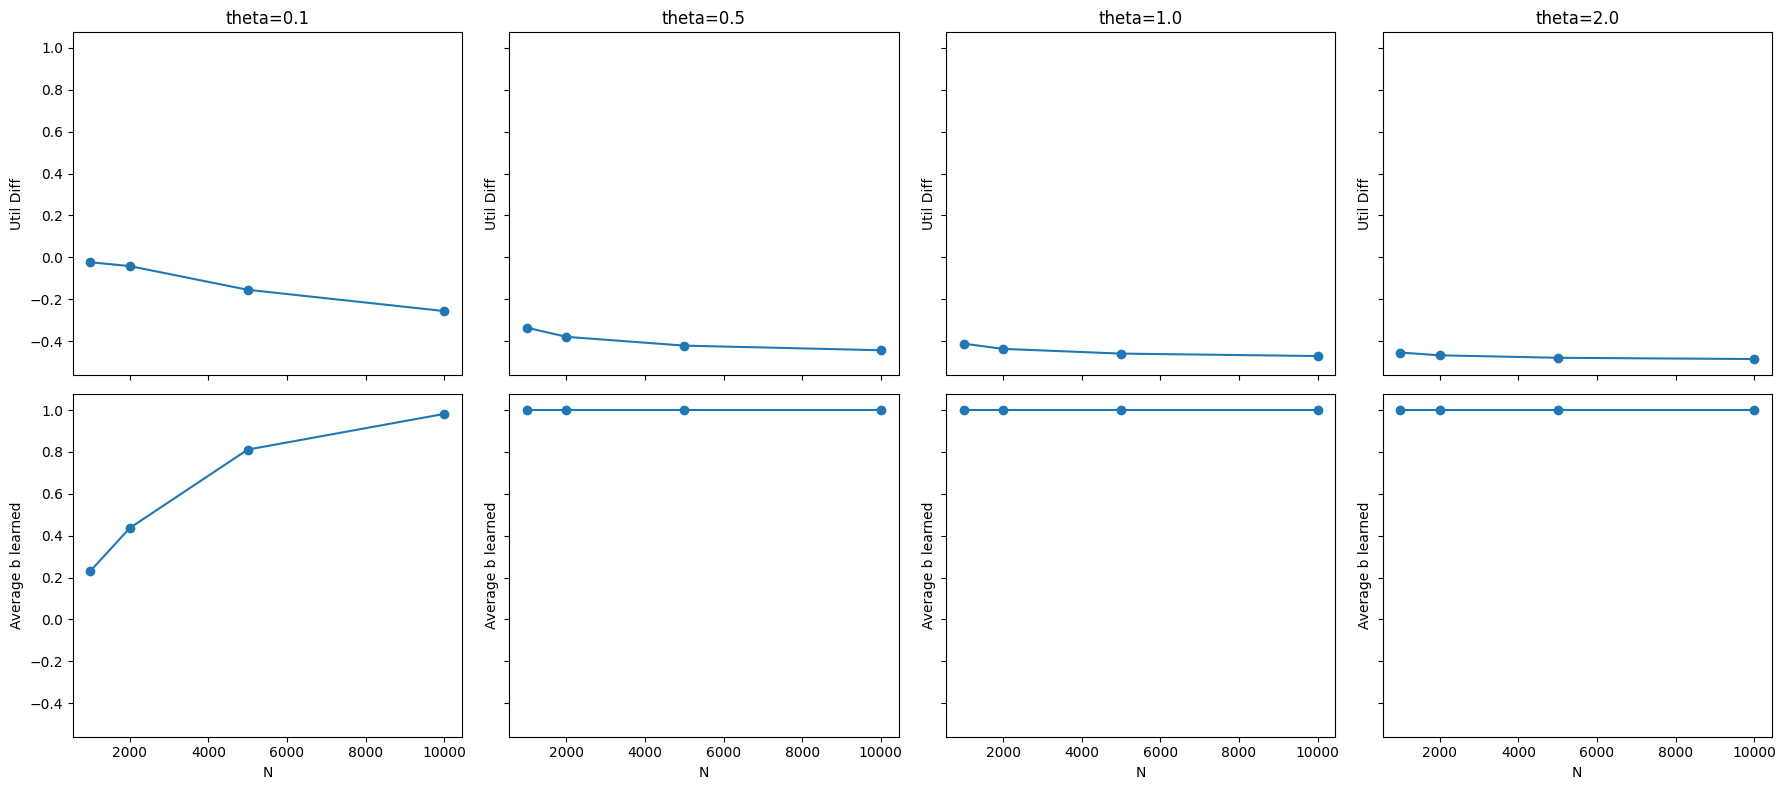

In [14]:
thetas = sorted(summary_results["theta"].unique())

fig, axes = plt.subplots(
    2,
    len(thetas),
    figsize=(4.5 * len(thetas), 8),
    sharex=True,
    sharey=True,
)

# make axes indexable as axes[row, col] even if len(thetas) == 1
if len(thetas) == 1:
    axes = axes.reshape(2, 1)

for i, theta in enumerate(thetas):
    subset = (
        summary_results[summary_results["theta"] == theta]
        .sort_values("N")
    )

    ax_top = axes[0, i]
    ax_bottom = axes[1, i]

    ax_top.plot(
        subset["N"],
        subset["util_diff"],   # replace with your actual column name
        marker="o",
    )

    ax_bottom.plot(
        subset["N"],
        subset["mean_b_hat_at_stop"],      # replace with your actual column name
        marker="o",
    )

    ax_top.set_title(f"theta={theta}")
    ax_top.set_ylabel("Util Diff")

    ax_bottom.set_xlabel("N")
    ax_bottom.set_ylabel("Average b learned")

plt.tight_layout()
plt.show()